<a href="https://colab.research.google.com/github/mscids2024pranita-hue/goa-rainfall-arima/blob/main/06_forecasting_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — Forecasting & Evaluation
**Project:** Goa Rainfall Forecasting using SARIMA
**Model:** SARIMA(0,0,0)(1,1,1,12)
**Step:** Forecast on test period, evaluate with MAE/RMSE/MAPE, residual diagnostics

In [1]:
!pip install netCDF4 xarray statsmodels -q

import zipfile, os, re
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from google.colab import files
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("imd_data")

DATA_DIR = "imd_data/imd_rainfall-20260513T063252Z-3-001/imd_rainfall/"
GOA_LAT_MIN, GOA_LAT_MAX = 14.9, 15.7
GOA_LON_MIN, GOA_LON_MAX = 73.7, 74.3

files_nc = sorted(os.listdir(DATA_DIR))
files_nc = [f for f in files_nc if re.match(r'RF25_ind\d{4}_rfp25\.nc$', f)]

daily_list = []
for fname in files_nc:
    ds_yr = xr.open_dataset(DATA_DIR + fname)
    goa_yr = ds_yr['RAINFALL'].sel(LATITUDE=slice(GOA_LAT_MIN, GOA_LAT_MAX), LONGITUDE=slice(GOA_LON_MIN, GOA_LON_MAX))
    goa_daily_yr = goa_yr.mean(dim=['LATITUDE','LONGITUDE'], skipna=True)
    times = pd.DatetimeIndex(ds_yr['TIME'].values)
    daily_list.append(pd.Series(goa_daily_yr.values, index=times))
    ds_yr.close()

daily_goa = pd.concat(daily_list).sort_index()
monthly_goa = daily_goa.resample('MS').sum()

for month in range(1, 13):
    monthly_goa[f'2005-{month:02d}-01'] = (monthly_goa[f'2004-{month:02d}-01'] + monthly_goa[f'2006-{month:02d}-01']) / 2

monthly_goa.name = 'rainfall_mm'
df = monthly_goa.to_frame()

train_size = int(len(df) * 0.8)
train = df['rainfall_mm'][:train_size]
test  = df['rainfall_mm'][train_size:]

model = SARIMAX(train, order=(0,0,0), seasonal_order=(1,1,1,12),
                enforce_stationarity=False, enforce_invertibility=False)
fitted_model = model.fit(disp=False)

print(f"Ready. Train: {len(train)} months, Test: {len(test)} months")
print(f"AIC: {fitted_model.aic:.3f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.0 MB/s eta 0:00:00


Saving imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip to imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip
Ready. Train: 336 months, Test: 84 months
AIC: 4153.275


In [2]:
# Forecast on the test period (84 months)
forecast_obj = fitted_model.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

forecast_mean.index = test.index
conf_int.index = test.index

print("First 6 forecast values:")
print(forecast_mean.head(6).round(1))

First 6 forecast values:
2019-01-01      0.7
2019-02-01      1.1
2019-03-01      8.1
2019-04-01      7.9
2019-05-01     78.4
2019-06-01    870.4
Freq: MS, Name: predicted_mean, dtype: float64


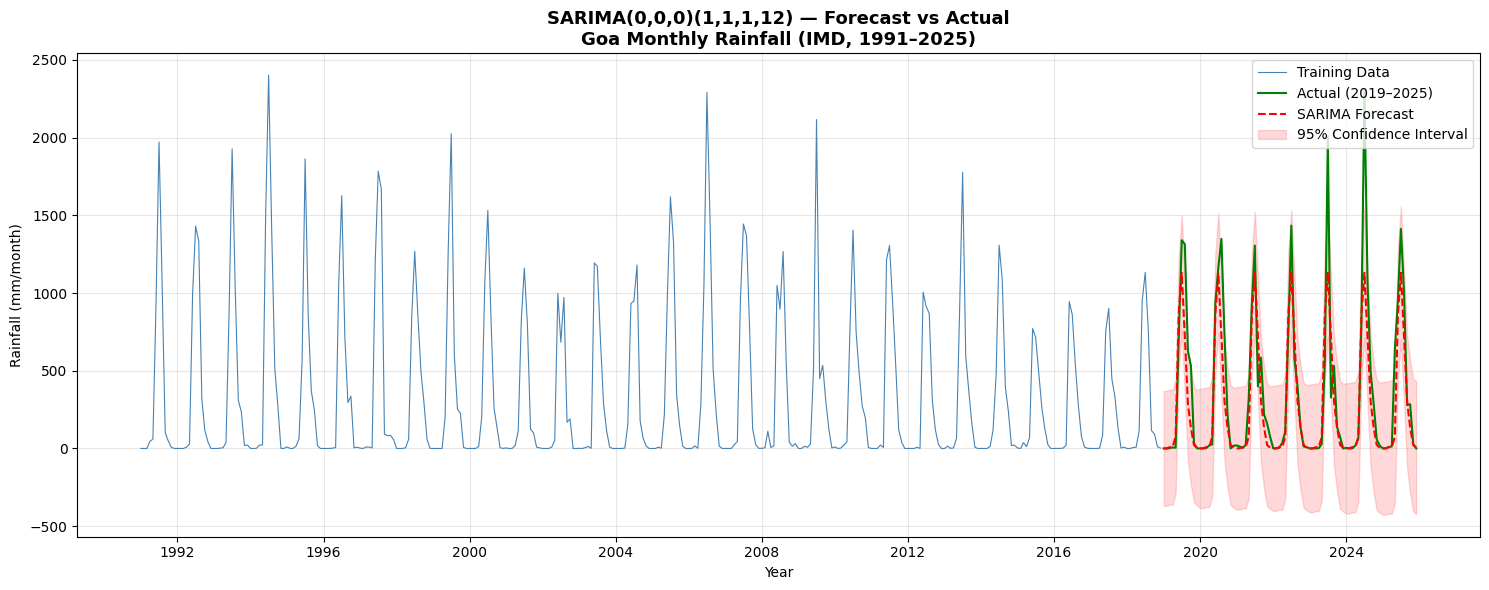

In [3]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train,
         color='steelblue', linewidth=0.8, label='Training Data')
plt.plot(test.index, test,
         color='green', linewidth=1.5, label='Actual (2019–2025)')
plt.plot(test.index, forecast_mean,
         color='red', linewidth=1.5, linestyle='--', label='SARIMA Forecast')
plt.fill_between(test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.15, label='95% Confidence Interval')

plt.title('SARIMA(0,0,0)(1,1,1,12) — Forecast vs Actual\nGoa Monthly Rainfall (IMD, 1991–2025)',
          fontsize=13, fontweight='bold')
plt.ylabel('Rainfall (mm/month)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('08_forecast_vs_actual.png', dpi=150)
plt.show()

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs((test - forecast_mean) / test.replace(0, np.nan))) * 100

print("="*40)
print("Model Evaluation Metrics")
print("="*40)
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"MAPE : {mape:.2f} %")

Model Evaluation Metrics
MAE  : 126.80 mm
RMSE : 241.19 mm
MAPE : 258.13 %


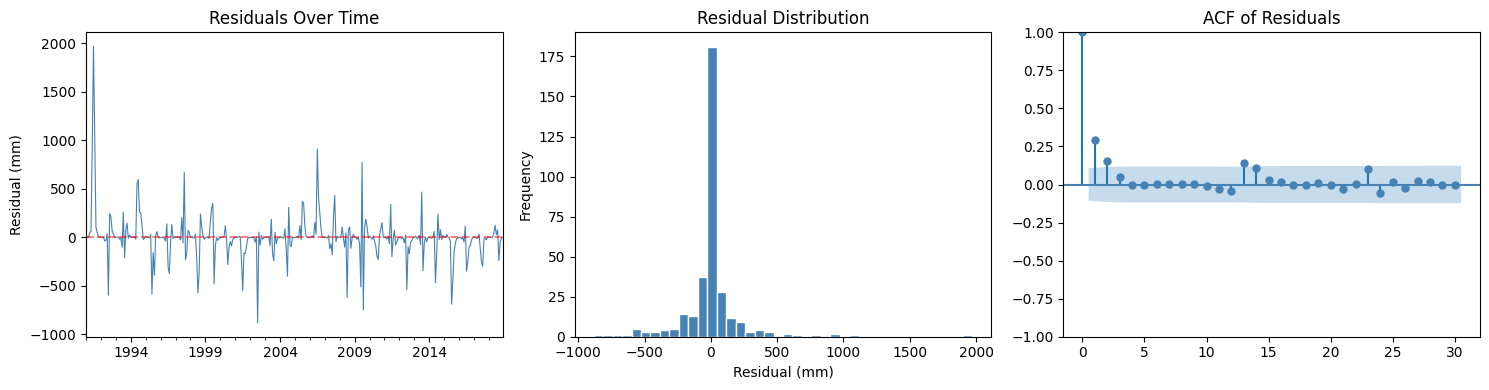

In [5]:
residuals = fitted_model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

residuals.plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Residual (mm)')

residuals.plot(kind='hist', bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (mm)')

plot_acf(residuals, lags=30, ax=axes[2], color='steelblue')
axes[2].set_title('ACF of Residuals')

plt.tight_layout()
plt.savefig('09_residual_diagnostics.png', dpi=150)
plt.show()

In [6]:
with open('10_evaluation_metrics.txt', 'w') as f:
    f.write('SARIMA(0,0,0)(1,1,1,12) — Evaluation Metrics\n')
    f.write('='*45 + '\n')
    f.write(f'MAE  : {mae:.2f} mm\n')
    f.write(f'RMSE : {rmse:.2f} mm\n')
    f.write(f'MAPE : {mape:.2f} % (unreliable due to near-zero dry months)\n')
    f.write('\nNotes:\n')
    f.write('- Ljung-Box passed: residuals have no significant autocorrelation\n')
    f.write('- ACF of residuals shows minor spikes at lag 1-2\n')
    f.write('- Heavy tails in residuals due to extreme monsoon events\n')
    f.write('- Confidence interval dips below zero: SARIMA limitation\n')

print("Evaluation metrics saved.")

Evaluation metrics saved.
